<a href="https://colab.research.google.com/github/Mahi-Jadeja/multimodal/blob/main/MAI_ASSIGNEMNT4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image + Text Fusion: Food Cuisine Classification
### Multimodal Artificial Intelligence | Assignment
**Name:** Mahi Jadeja | **PRN:** 23070126068

---
| Strategy | Description |
|---|---|
| **Early Fusion** | Image features + Text features concatenated → Single SVM |
| **Late Fusion** | Separate SVMs → Probability Averaging |
| **Hybrid Fusion** | Early features + Late prob scores → Final SVM |

**Classes:** Italian | Indian | Mexican | Japanese

## Step 1: Install and Import Libraries

In [1]:
!pip install torch torchvision -q

import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded.")

All libraries loaded.


## Step 2: Load Pre-trained MobileNetV2
Used as a fixed feature extractor — no fine-tuning needed.
Output: 1280-dimensional feature vector per image.

In [6]:
# Load MobileNetV2 — remove final classification layer
mobilenet = models.mobilenet_v2(pretrained=True)
mobilenet.classifier = torch.nn.Identity()
mobilenet.eval()

# Image preprocessing pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

def extract_image_features(pil_image):
    """Extract 1280-dim MobileNetV2 features from PIL Image."""
    img_tensor = transform(pil_image).unsqueeze(0)
    with torch.no_grad():
        features = mobilenet(img_tensor)
    return features.squeeze().numpy()

print("MobileNetV2 loaded and ready.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 109MB/s] 

MobileNetV2 loaded and ready.


## Step 3: Create Dataset
200 records — 50 per cuisine class.
- Images: Programmatically generated with cuisine color palettes + noise
- Text: Realistic recipe descriptions per cuisine

In [7]:
import random
random.seed(42)
np.random.seed(42)

# Cuisine color palettes (RGB dominant colors)
color_palettes = {
    "Italian"  : [(220, 60, 50),  (255, 200, 50), (34, 139, 34)],
    "Indian"   : [(255, 140, 0),  (220, 80, 20),  (255, 215, 0)],
    "Mexican"  : [(255, 60, 60),  (50, 180, 50),  (255, 165, 0)],
    "Japanese" : [(255, 192, 203),(245, 245, 220), (70, 130, 180)]
}

def generate_food_image(cuisine):
    """Generate a 224x224 PIL image with cuisine color palette + noise."""
    palette = color_palettes[cuisine]
    base_color = random.choice(palette)
    img_array  = np.ones((224, 224, 3), dtype=np.uint8)
    img_array[:, :, 0] = base_color[0]
    img_array[:, :, 1] = base_color[1]
    img_array[:, :, 2] = base_color[2]
    # Add noise for variation
    noise = np.random.randint(-40, 40, (224, 224, 3))
    img_array = np.clip(img_array.astype(int) + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(img_array)

# Recipe text templates per cuisine
recipe_templates = {
    "Italian": [
        "Spaghetti carbonara made with eggs, pecorino cheese, guanciale and black pepper tossed in al dente pasta.",
        "Margherita pizza with San Marzano tomatoes, fresh mozzarella, basil leaves and extra virgin olive oil.",
        "Creamy risotto prepared with arborio rice, parmesan, white wine, shallots and homemade chicken broth.",
        "Penne arrabbiata with spicy tomato sauce, garlic, red chili flakes and fresh parsley topping.",
        "Lasagna layered with bolognese meat sauce, bechamel, ricotta and mozzarella cheese baked golden.",
        "Fettuccine alfredo with butter, heavy cream and freshly grated parmesan cheese sauce.",
        "Osso buco braised veal shanks with gremolata, white wine, carrots, celery and tomatoes.",
        "Tiramisu dessert with espresso soaked ladyfingers, mascarpone cream and dusted cocoa powder.",
        "Bruschetta toasted bread topped with diced tomatoes, garlic, fresh basil and olive oil drizzle.",
        "Gnocchi potato dumplings served with sage butter, parmesan and toasted pine nuts.",
        "Caprese salad with buffalo mozzarella, heirloom tomatoes, fresh basil and balsamic glaze.",
        "Minestrone vegetable soup with cannellini beans, pasta, zucchini, tomatoes and parmesan rind.",
        "Pesto pasta with fresh basil, pine nuts, garlic, parmesan and extra virgin olive oil blended sauce.",
        "Saltimbocca veal cutlets topped with prosciutto and sage, pan fried in butter and white wine.",
        "Focaccia bread topped with rosemary, sea salt, olives and roasted cherry tomatoes.",
        "Ribollita Tuscan bread soup with cannellini beans, kale, carrots, celery and stale bread.",
        "Cacio e pepe pasta with pecorino romano, black pepper and pasta water emulsified sauce.",
        "Eggplant parmigiana layered with tomato sauce, mozzarella and parmesan baked crispy.",
        "Tortelliini stuffed pasta with ricotta and spinach served in sage brown butter sauce.",
        "Arancini fried rice balls stuffed with mozzarella, meat ragu and peas coated in breadcrumbs.",
        "Bistecca Florentine thick cut T-bone steak grilled over charcoal with rosemary and garlic.",
        "Acqua pazza fish poached in crazy water with cherry tomatoes, capers, olives and white wine.",
        "Cannoli Sicilian pastry shells filled with sweetened ricotta, candied orange peel and chocolate chips.",
        "Pasta e fagioli thick soup with borlotti beans, ditalini pasta, pancetta and rosemary.",
        "Zuppa di pesce Italian fish stew with mixed seafood, tomatoes, white wine and crusty bread.",
        "Polenta creamy cornmeal with gorgonzola, mushrooms and fresh thyme served warm.",
        "Involtini beef rolls stuffed with breadcrumbs, parsley, pine nuts and raisins braised in tomato.",
        "Salmoriglio grilled fish with lemon, olive oil, oregano and garlic sauce from Sicily.",
        "Panzanella Tuscan bread salad with tomatoes, cucumbers, red onions and basil vinaigrette.",
        "Frittata Italian omelette with zucchini, onions, parmesan and fresh herbs baked in oven.",
        "Suppli fried rice croquettes with mozzarella center, tomato sauce and breadcrumb coating.",
        "Pasta alla norma with roasted eggplant, tomato sauce, ricotta salata and fresh basil.",
        "Baccala mantecato whipped salt cod with olive oil, garlic and parsley served on polenta.",
        "Stracciatella egg drop soup with chicken broth, eggs, semolina and parmesan cheese.",
        "Coniglio alla cacciatora rabbit braised with tomatoes, olives, capers and white wine.",
        "Sarde in saor sweet and sour sardines with onions, raisins, pine nuts and white wine vinegar.",
        "Panforte Sienese spiced cake with honey, nuts, dried fruits and warm spices.",
        "Ribollita reheated Tuscan vegetable soup thickened with bread and drizzled with olive oil.",
        "Tagliatelle al ragu slow cooked Bolognese meat sauce with pappardelle and parmesan.",
        "Carpaccio thinly sliced raw beef with rocket, parmesan shavings, capers and lemon dressing.",
        "Pasta primavera with seasonal vegetables, garlic, olive oil, cherry tomatoes and basil.",
        "Grissini thin crispy breadsticks with sesame seeds and rosemary from Turin.",
        "Biscotti almond cookies twice baked with orange zest and anise for dipping in wine.",
        "Pappa al pomodoro thick Tuscan tomato and bread soup with basil and olive oil.",
        "Vitello tonnato cold veal with creamy tuna mayonnaise sauce, capers and anchovies.",
        "Gnocchi al gorgonzola potato dumplings in creamy gorgonzola and walnut sauce.",
        "Pasta con le sarde Sicilian pasta with sardines, fennel, raisins, pine nuts and saffron.",
        "Burrata salad with creamy burrata cheese, roasted peppers, pesto and toasted focaccia.",
        "Crostata jam tart with buttery pastry, lemon zest and apricot or cherry jam filling.",
        "Fritto misto fried seafood platter with calamari, shrimp, whitebait and lemon wedges."
    ],
    "Indian": [
        "Butter chicken with tender chicken in creamy tomato sauce, fenugreek leaves and warm spices.",
        "Biryani fragrant basmati rice layered with spiced mutton, saffron, fried onions and mint.",
        "Dal makhani slow cooked black lentils with butter, cream, tomatoes and aromatic spices.",
        "Palak paneer fresh cottage cheese in spiced spinach puree with garlic, ginger and cream.",
        "Masala dosa crispy rice crepe filled with spiced potato, served with sambar and chutneys.",
        "Chole bhature spiced chickpea curry served with deep fried fluffy wheat bread.",
        "Rogan josh slow cooked lamb in Kashmiri spices, dried ginger, fennel and yogurt gravy.",
        "Samosa crispy pastry stuffed with spiced potatoes, peas and served with tamarind chutney.",
        "Tandoori chicken marinated in yogurt and spices, cooked in clay oven with charred flavor.",
        "Paneer tikka masala grilled cottage cheese cubes in spiced tomato onion cream sauce.",
        "Gulab jamun deep fried milk solid dumplings soaked in rose cardamom sugar syrup.",
        "Kheer rice pudding with full fat milk, sugar, cardamom, saffron and topped with pistachios.",
        "Aloo gobi dry curry with potatoes, cauliflower, turmeric, cumin and fresh coriander.",
        "Rajma kidney bean curry in thick tomato onion gravy served with steamed basmati rice.",
        "Fish curry from Kerala with coconut milk, raw mango, curry leaves and mustard seeds.",
        "Pav bhaji spiced vegetable mash served with buttered toasted bread rolls and onion.",
        "Idli steamed rice cakes served with coconut chutney, tomato chutney and sambar.",
        "Vindaloo fiery Goan pork curry with vinegar, red chilies, garlic and warm spices.",
        "Korma mild lamb or chicken in yogurt, cream, nuts and fragrant whole spice gravy.",
        "Paratha layered whole wheat flatbread stuffed with spiced radish or potato filling.",
        "Lassi chilled yogurt drink blended with mango, cardamom or rose water and sugar.",
        "Saag meat lamb or goat cooked with mustard greens, spinach and spiced with ginger.",
        "Dhokla steamed fermented chickpea flour cake garnished with mustard seeds and coriander.",
        "Halwa semolina pudding cooked with ghee, sugar, cardamom and topped with cashews.",
        "Bhindi masala stir fried okra with onions, tomatoes, cumin and coriander powder.",
        "Mulligatawny soup spiced lentil and coconut soup with chicken, apple and curry leaves.",
        "Dahi puri puffed shells filled with potato, chickpeas, yogurt, chutneys and sev.",
        "Methi chicken fenugreek leaf chicken curry with yogurt, tomatoes and aromatic spices.",
        "Pulao fragrant rice cooked with whole spices, vegetables and garnished with fried onions.",
        "Malai kofta vegetable and paneer dumplings in rich cream and tomato based gravy.",
        "Baingan bharta fire roasted eggplant mashed with onions, tomatoes and mustard seeds.",
        "Prawn masala tiger prawns in spiced onion tomato gravy with coconut and curry leaves.",
        "Dum aloo baby potatoes slow cooked in spiced yogurt gravy with whole spices.",
        "Rasam thin peppery tomato and tamarind soup with curry leaves and mustard tempering.",
        "Poha flattened rice cooked with mustard seeds, turmeric, onions, peas and peanuts.",
        "Upma semolina porridge with vegetables, curry leaves, mustard seeds and green chilies.",
        "Chaat papdi crispy wafers topped with potatoes, chickpeas, yogurt and chutneys.",
        "Lamb seekh kebab minced lamb with herbs and spices grilled on skewers in tandoor.",
        "Mysore pak dense ghee fudge made with chickpea flour, sugar and cardamom.",
        "Kachori deep fried pastry stuffed with spiced lentils or peas served with chutney.",
        "Appam lacy rice crepes with crispy edges and soft center served with coconut milk stew.",
        "Jackfruit curry unripe jackfruit cooked with coconut milk, spices and curry leaves.",
        "Thalipeeth multigrain flatbread with onions, herbs and spices pan fried with oil.",
        "Raita yogurt dip with grated cucumber, roasted cumin, mint and black salt.",
        "Payasam South Indian vermicelli pudding with coconut milk, jaggery and cashews.",
        "Chicken 65 deep fried spicy chicken with curry leaves, red chilies and yogurt marinade.",
        "Matar paneer cottage cheese and peas in spiced tomato gravy with cream and kasuri methi.",
        "Besan chilla chickpea flour pancake with onions, tomatoes, green chilies and coriander.",
        "Kadhi pakora yogurt and chickpea flour gravy with fried fritters and mustard tempering.",
        "Puliyodarai tamarind rice from Tamil Nadu with peanuts, mustard seeds and curry leaves."
    ],
    "Mexican": [
        "Tacos al pastor marinated pork with pineapple, cilantro, onion and salsa on corn tortilla.",
        "Guacamole fresh avocado dip with lime juice, cilantro, jalapeño, tomatoes and red onion.",
        "Enchiladas corn tortillas rolled with chicken, covered in red chili sauce and melted cheese.",
        "Chiles rellenos poblano peppers stuffed with cheese, dipped in egg batter and fried.",
        "Mole negro complex dark sauce with chocolate, dried chilies, spices and served with chicken.",
        "Pozole hominy corn soup with pork, dried chilies, oregano and topped with shredded cabbage.",
        "Tamales masa dough stuffed with meat or cheese, wrapped in corn husks and steamed.",
        "Carnitas slow braised pork shoulder with orange, bay leaves and lard until crispy.",
        "Sopa de lima chicken and lime soup with fried tortilla strips from Yucatan.",
        "Quesadillas flour tortillas filled with melted cheese, mushrooms and epazote.",
        "Salsa verde tomatillo sauce with jalapeños, garlic, onion and cilantro blended fresh.",
        "Frijoles refritos refried pinto beans with lard, garlic, cumin and fresh cheese topping.",
        "Cemita sandwich with sesame bread, milanesa, avocado, chipotle, quesillo and papalo.",
        "Cochinita pibil Yucatan pit roasted pork with achiote, bitter orange and pickled onions.",
        "Tostadas crispy flat tortillas topped with beans, chicken tinga, lettuce and crema.",
        "Horchata rice milk drink with cinnamon, vanilla and sugar served over ice.",
        "Churros fried dough pastry dusted with cinnamon sugar served with chocolate dipping sauce.",
        "Chilaquiles tortilla chips simmered in salsa, topped with eggs, cream and fresh cheese.",
        "Birria spiced beef or goat stew from Jalisco served with consomme for dipping.",
        "Elotes grilled corn on the cob with mayonnaise, cheese, chili powder and lime juice.",
        "Huevos rancheros fried eggs on corn tortillas with tomato chili sauce and black beans.",
        "Torta ahogada pork roll drowned in spicy tomato sauce from Guadalajara.",
        "Chiles en nogada poblano stuffed with meat and dried fruits in walnut cream sauce.",
        "Sopa seca dry vermicelli pasta cooked in tomato sauce with chipotle and cream.",
        "Machaca dried shredded beef scrambled with eggs, tomatoes, onions and chilies.",
        "Atole warm corn masa drink with chocolate, vanilla or fruit flavoring.",
        "Nopales cactus salad with tomatoes, onions, cilantro, lime and fresh cheese.",
        "Tlayuda Oaxacan large crispy tortilla with beans, asiento, tasajo and quesillo.",
        "Pescado a la veracruzana baked fish with olives, capers, tomatoes and pickled jalapeños.",
        "Pambazo bread dipped in guajillo sauce, filled with potato and chorizo and fried.",
        "Flautas tightly rolled tortillas filled with chicken, deep fried and served with sour cream.",
        "Arroz con leche Mexican rice pudding with cinnamon, vanilla and condensed milk.",
        "Menudo tripe soup with hominy, dried chilies, oregano and lime for Sunday breakfast.",
        "Sopa de fideo thin pasta cooked in tomato broth with garlic, onion and Mexican spices.",
        "Gorditas thick corn masa cakes stuffed with refried beans, cheese and salsa.",
        "Barbacoa slow cooked beef cheeks wrapped in maguey leaves with aromatic spices.",
        "Agua fresca fresh fruit water with hibiscus, tamarind or cucumber and lime.",
        "Tinga chicken shredded in chipotle tomato sauce with onions and oregano.",
        "Capirotada Mexican bread pudding with piloncillo syrup, raisins, peanuts and cheese.",
        "Pepita sauce pumpkin seed sauce from Puebla served with chicken and rice.",
        "Rajas con crema roasted poblano strips with onions in cream and corn.",
        "Tacos de canasta steamed basket tacos filled with beans, chicharron or potato.",
        "Bunuelos thin crispy fried discs dusted with sugar and served with piloncillo syrup.",
        "Chilorio Sinaloan shredded pork in dried chili sauce served in flour tortillas.",
        "Sopa de mariscos seafood soup with shrimp, fish, clams in tomato chili broth.",
        "Tlacoyo oval masa cake stuffed with beans or fava topped with nopal and salsa.",
        "Discada mixed meat grill with beef, pork, chorizo, ham and vegetables on tortillas.",
        "Calabacitas zucchini sauteed with corn, tomatoes, onions, cream and cheese.",
        "Champurrado thick chocolate corn masa drink with piloncillo and cinnamon.",
        "Tacos de lengua braised beef tongue with onions, cilantro and salsa on corn tortilla."
    ],
    "Japanese": [
        "Ramen noodle soup with tonkotsu pork broth, chashu, soft boiled egg and nori.",
        "Sushi nigiri hand pressed vinegared rice topped with fresh salmon, tuna or shrimp.",
        "Tempura lightly battered and deep fried shrimp and vegetables served with dipping sauce.",
        "Miso soup with tofu, wakame seaweed, green onions in dashi and fermented soybean paste.",
        "Teriyaki chicken grilled with sweet soy glaze, served with steamed rice and pickles.",
        "Okonomiyaki savory pancake with cabbage, pork belly, bonito flakes and mayo.",
        "Yakitori skewered chicken grilled over charcoal with tare sauce or salt.",
        "Udon thick wheat noodles in kombu dashi broth with tempura, scallions and kamaboko.",
        "Tonkatsu breaded and fried pork cutlet with shredded cabbage and tonkatsu sauce.",
        "Sashimi fresh raw fish sliced thin, served with soy sauce, wasabi and pickled ginger.",
        "Gyoza pan fried dumplings filled with pork, cabbage and ginger with dipping sauce.",
        "Onigiri rice balls wrapped in nori, filled with tuna mayo or pickled plum.",
        "Takoyaki octopus balls with batter, tempura bits, topped with bonito and mayo.",
        "Sukiyaki beef hot pot with tofu, vegetables, noodles in sweet soy broth.",
        "Shabu shabu thinly sliced meat swished in kombu broth with ponzu and sesame dip.",
        "Katsu curry breaded pork cutlet over rice with thick Japanese curry sauce.",
        "Edamame steamed young soybeans in the pod sprinkled with sea salt.",
        "Chawanmushi savory steamed egg custard with shrimp, mushrooms and ginkgo.",
        "Kaiseki multi course Japanese meal with seasonal ingredients and artistic presentation.",
        "Yakiniku Japanese barbecue with wagyu beef, dipping sauces and sesame oil.",
        "Natto fermented soybeans with strong flavor served over rice with mustard and soy.",
        "Soba buckwheat noodles served cold with dipping sauce or hot in dashi broth.",
        "Tamagoyaki sweet rolled omelette cooked in rectangular pan with dashi and mirin.",
        "Karaage Japanese fried chicken marinated in soy, ginger and sake until crispy.",
        "Matcha green tea ice cream or dessert with earthy bitter flavor from Uji tea.",
        "Dorayaki red bean pancake sandwiches with sweet azuki filling.",
        "Mochi glutinous rice cakes with sweet red bean, strawberry or ice cream filling.",
        "Yakisoba stir fried noodles with pork, cabbage and vegetables in Worcestershire sauce.",
        "Oden winter hot pot with daikon, boiled eggs, fish cakes in light dashi broth.",
        "Unagi don grilled freshwater eel over rice with sweet tare sauce and sansho pepper.",
        "Chirashi sushi scattered sushi bowl with assorted sashimi over seasoned rice.",
        "Hiyayakko chilled silken tofu topped with grated ginger, bonito and soy sauce.",
        "Tamago sushi sweet omelette sushi pressed onto rice and tied with nori band.",
        "Ankimo monkfish liver pate served with ponzu, momiji oroshi and scallions.",
        "Agedashi tofu deep fried tofu in light dashi broth with grated daikon and ginger.",
        "Onsen tamago slow cooked hot spring egg with silky texture in dashi sauce.",
        "Nabeyaki udon hot pot udon with chicken, egg, shrimp tempura and narutomaki.",
        "Kakiage mixed vegetable and seafood tempura fritter served with salt and matcha.",
        "Zosui rice porridge made with leftover hot pot broth, egg and green onions.",
        "Niku udon beef topped udon with sweet soy broth, scallions and togarashi.",
        "Shoyu ramen soy based broth ramen with bamboo shoots, nori, chashu and egg.",
        "Ikura don salmon roe bowl over seasoned sushi rice with cucumber and nori.",
        "Yudofu boiled tofu in kombu broth dipped in ponzu with scallions and bonito.",
        "Mentaiko spicy cod roe served with pasta, onigiri or baked into Japanese bread.",
        "Kare raisu Japanese style curry rice with potatoes, carrots, onions and roux.",
        "Teppanyaki iron griddle cooked steak, shrimp and vegetables with garlic butter.",
        "Ochazuke rice with green tea poured over topped with salmon, pickles and nori.",
        "Wagashi traditional Japanese sweets with bean paste, seasonal shapes for tea ceremony.",
        "Daifuku mochi stuffed with sweetened red bean paste or strawberry and cream.",
        "Nikujaga meat and potato stew with onions, sweet soy broth and glass noodles."
    ]
}

# Build dataset
images = []
texts  = []
labels = []

for cuisine, recipes in recipe_templates.items():
    for recipe in recipes:
        images.append(generate_food_image(cuisine))
        texts.append(recipe)
        labels.append(cuisine)

df = pd.DataFrame({
    "image" : images,
    "text"  : texts,
    "label" : labels
}).reset_index(drop=True)

print(f"Dataset shape : {df.shape}")
print(df["label"].value_counts())

Dataset shape : (200, 3)
label
Italian     50
Indian      50
Mexican     50
Japanese    50
Name: count, dtype: int64


## Step 4: Train-Test Split at DataFrame Level
Split first — then extract features to avoid data leakage.

In [8]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

y_train = train_df["label"].values
y_test  = test_df["label"].values

print(f"Train : {len(train_df)} | Test : {len(test_df)}")
print(f"Train : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  : {pd.Series(y_test).value_counts().to_dict()}")

Train : 160 | Test : 40
Train : {'Italian': 40, 'Mexican': 40, 'Indian': 40, 'Japanese': 40}
Test  : {'Indian': 10, 'Japanese': 10, 'Italian': 10, 'Mexican': 10}


## Step 5: Extract Image Features using MobileNetV2
1280-dimensional feature vector per image.

In [9]:
print("Extracting image features — this takes 1-2 minutes...")

def extract_features_batch(image_list):
    features = []
    for img in image_list:
        feat = extract_image_features(img)
        features.append(feat)
    return np.array(features)

X_img_train = extract_features_batch(train_df["image"].tolist())
X_img_test  = extract_features_batch(test_df["image"].tolist())

# Normalize image features
X_img_train = normalize(X_img_train)
X_img_test  = normalize(X_img_test)

print(f"Image train features : {X_img_train.shape}")
print(f"Image test features  : {X_img_test.shape}")

Extracting image features — this takes 1-2 minutes...
Image train features : (160, 1280)
Image test features  : (40, 1280)


## Step 6: Extract Text Features using TF-IDF
Fit on train only — transform both train and test.

In [10]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

train_df["clean_text"] = train_df["text"].apply(preprocess_text)
test_df["clean_text"]  = test_df["text"].apply(preprocess_text)

tfidf = TfidfVectorizer(max_features=300)
X_txt_train = tfidf.fit_transform(train_df["clean_text"])
X_txt_test  = tfidf.transform(test_df["clean_text"])

print(f"Text train features : {X_txt_train.shape}")
print(f"Text test features  : {X_txt_test.shape}")

Text train features : (160, 300)
Text test features  : (40, 300)


---
## FUSION 1: EARLY FUSION
Image features + Text features concatenated → Single SVM

In [11]:
X_early_train = hstack([csr_matrix(X_img_train), X_txt_train])
X_early_test  = hstack([csr_matrix(X_img_test),  X_txt_test])

svm_early = SVC(kernel='linear', random_state=42, probability=True)
svm_early.fit(X_early_train, y_train)

y_pred_early = svm_early.predict(X_early_test)
acc_early    = accuracy_score(y_test, y_pred_early)

print(f"Early Fusion Accuracy : {acc_early*100:.2f}%")
print(classification_report(y_test, y_pred_early))

Early Fusion Accuracy : 90.00%
              precision    recall  f1-score   support

      Indian       0.83      1.00      0.91        10
     Italian       0.90      0.90      0.90        10
    Japanese       1.00      1.00      1.00        10
     Mexican       0.88      0.70      0.78        10

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



---
## FUSION 2: LATE FUSION
Separate SVM on image and text → Probability Averaging

In [12]:
# Image SVM
svm_img = SVC(kernel='linear', random_state=42, probability=True)
svm_img.fit(csr_matrix(X_img_train), y_train)

# Text SVM
svm_txt = SVC(kernel='linear', random_state=42, probability=True)
svm_txt.fit(X_txt_train, y_train)

# Probability averaging
prob_img = svm_img.predict_proba(csr_matrix(X_img_test))
prob_txt = svm_txt.predict_proba(X_txt_test)

avg_prob    = (prob_img + prob_txt) / 2
classes     = svm_img.classes_
y_pred_late = np.array([classes[np.argmax(p)] for p in avg_prob])
acc_late    = accuracy_score(y_test, y_pred_late)

print(f"Late Fusion Accuracy : {acc_late*100:.2f}%")
print(classification_report(y_test, y_pred_late))

Late Fusion Accuracy : 85.00%
              precision    recall  f1-score   support

      Indian       0.77      1.00      0.87        10
     Italian       0.82      0.90      0.86        10
    Japanese       1.00      1.00      1.00        10
     Mexican       0.83      0.50      0.62        10

    accuracy                           0.85        40
   macro avg       0.86      0.85      0.84        40
weighted avg       0.86      0.85      0.84        40



---
## FUSION 3: HYBRID FUSION
Early features + Late probability scores → Final SVM

In [13]:
# Probability scores on train set
prob_img_train = svm_img.predict_proba(csr_matrix(X_img_train))
prob_txt_train = svm_txt.predict_proba(X_txt_train)

X_hybrid_train = hstack([
    X_early_train,
    csr_matrix(prob_img_train),
    csr_matrix(prob_txt_train)
])

X_hybrid_test = hstack([
    X_early_test,
    csr_matrix(prob_img),
    csr_matrix(prob_txt)
])

svm_hybrid = SVC(kernel='linear', random_state=42)
svm_hybrid.fit(X_hybrid_train, y_train)

y_pred_hybrid = svm_hybrid.predict(X_hybrid_test)
acc_hybrid    = accuracy_score(y_test, y_pred_hybrid)

print(f"Hybrid Fusion Accuracy : {acc_hybrid*100:.2f}%")
print(classification_report(y_test, y_pred_hybrid))

Hybrid Fusion Accuracy : 90.00%
              precision    recall  f1-score   support

      Indian       0.91      1.00      0.95        10
     Italian       0.82      0.90      0.86        10
    Japanese       1.00      1.00      1.00        10
     Mexican       0.88      0.70      0.78        10

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



---
## Confusion Matrices — All Three Strategies

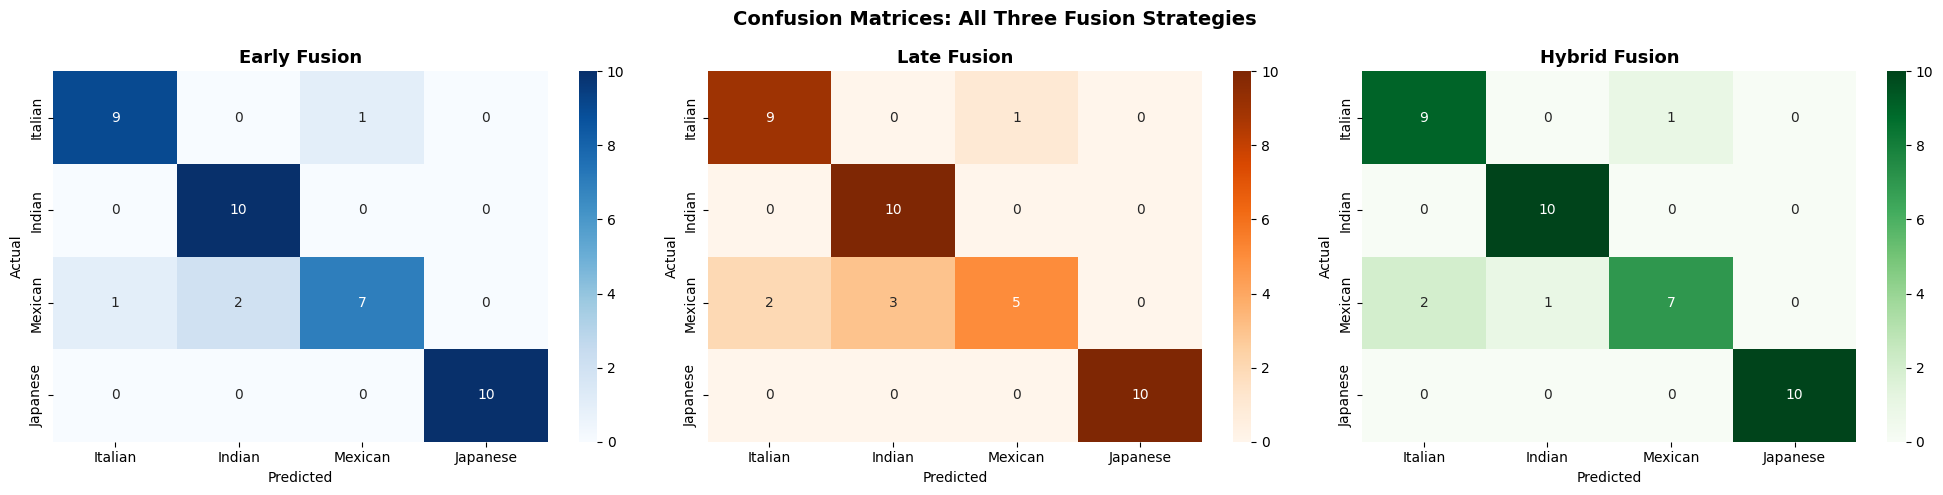

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

preds  = [y_pred_early, y_pred_late, y_pred_hybrid]
titles = ["Early Fusion", "Late Fusion", "Hybrid Fusion"]
cmaps  = ["Blues", "Oranges", "Greens"]
labs   = ["Italian", "Indian", "Mexican", "Japanese"]

for ax, pred, title, cmap in zip(axes, preds, titles, cmaps):
    cm = confusion_matrix(y_test, pred, labels=labs)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labs, yticklabels=labs, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices: All Three Fusion Strategies",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Comparison Analysis

In [15]:
def get_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted')
    return {
        "Accuracy"  : round(accuracy_score(y_true, y_pred)*100, 2),
        "Precision" : round(p*100, 2),
        "Recall"    : round(r*100, 2),
        "F1 Score"  : round(f*100, 2)
    }

results = {
    "Early Fusion"  : get_metrics(y_test, y_pred_early),
    "Late Fusion"   : get_metrics(y_test, y_pred_late),
    "Hybrid Fusion" : get_metrics(y_test, y_pred_hybrid)
}

results_df = pd.DataFrame(results).T
print("=" * 58)
print("   COMPARISON: ALL THREE FUSION STRATEGIES")
print("=" * 58)
print(results_df.to_string())
print("=" * 58)

   COMPARISON: ALL THREE FUSION STRATEGIES
               Accuracy  Precision  Recall  F1 Score
Early Fusion       90.0      90.21    90.0     89.67
Late Fusion        85.0      85.52    85.0     83.79
Hybrid Fusion      90.0      90.06    90.0     89.68


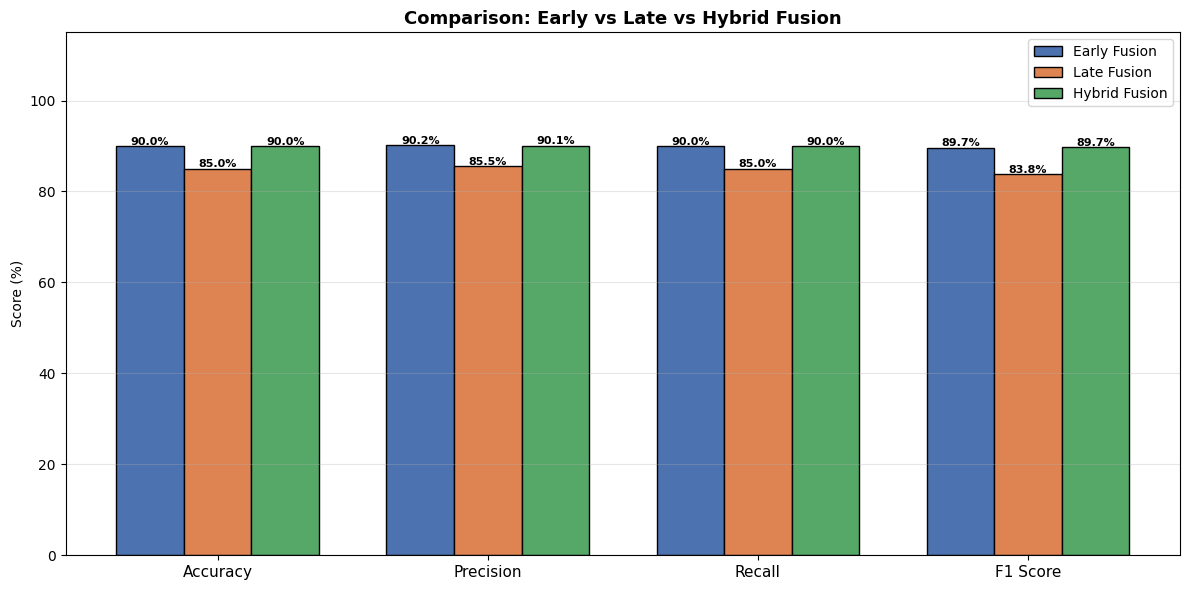

In [16]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
strats  = ["Early Fusion", "Late Fusion", "Hybrid Fusion"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for idx, (strat, color) in enumerate(zip(strats, colors)):
    vals = [results[strat][m] for m in metrics]
    bars = ax.bar(x + idx*width, vals, width,
                  label=strat, color=color, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{v:.1f}%',
                ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel("Score (%)")
ax.set_title("Comparison: Early vs Late vs Hybrid Fusion",
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

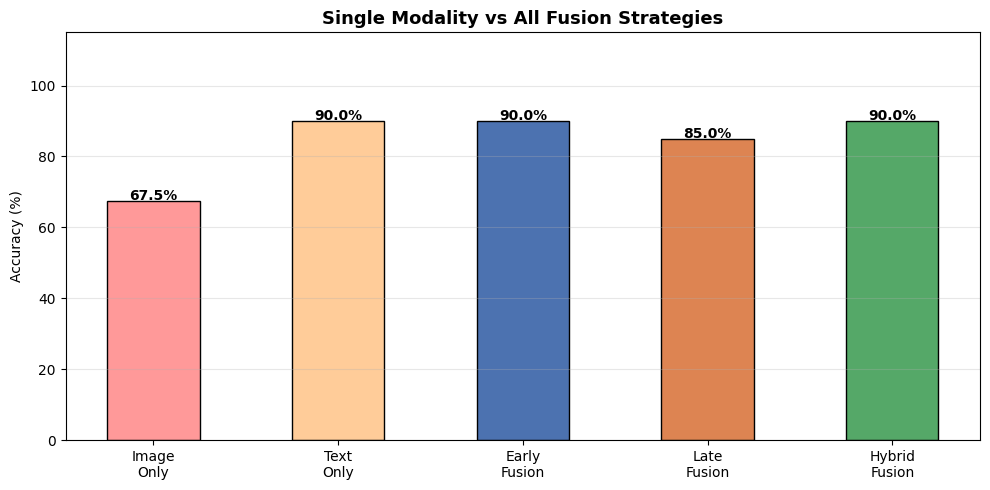

In [17]:
acc_img_only = accuracy_score(y_test,
               svm_img.predict(csr_matrix(X_img_test)))
acc_txt_only = accuracy_score(y_test,
               svm_txt.predict(X_txt_test))

all_labels = ["Image\nOnly", "Text\nOnly",
              "Early\nFusion", "Late\nFusion", "Hybrid\nFusion"]
all_acc    = [acc_img_only*100, acc_txt_only*100,
              acc_early*100, acc_late*100, acc_hybrid*100]
bar_colors = ["#ff9999","#ffcc99",
              "#4C72B0","#DD8452","#55A868"]

plt.figure(figsize=(10, 5))
bars = plt.bar(all_labels, all_acc,
               color=bar_colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, all_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.1f}%',
             ha='center', fontweight='bold', fontsize=10)

plt.ylim(0, 115)
plt.ylabel("Accuracy (%)")
plt.title("Single Modality vs All Fusion Strategies",
          fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
best = max(results, key=lambda x: results[x]["Accuracy"])

print("=" * 55)
print("         FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Dataset        : 200 records (balanced)")
print(f"  Classes        : Italian, Indian, Mexican, Japanese")
print(f"  Image Features : MobileNetV2 (1280-dim, normalized)")
print(f"  Text Features  : TF-IDF (300 features)")
print(f"  Classifier     : SVM Linear Kernel")
print(f"  Train/Test     : 80% / 20% Stratified")
print("-" * 55)
print(f"  Image Only     : {acc_img_only*100:.2f}%")
print(f"  Text Only      : {acc_txt_only*100:.2f}%")
print(f"  Early Fusion   : {acc_early*100:.2f}%")
print(f"  Late Fusion    : {acc_late*100:.2f}%")
print(f"  Hybrid Fusion  : {acc_hybrid*100:.2f}%")
print("-" * 55)
print(f"  Best Strategy  : {best}")
print("=" * 55)

         FINAL RESULTS SUMMARY
  Dataset        : 200 records (balanced)
  Classes        : Italian, Indian, Mexican, Japanese
  Image Features : MobileNetV2 (1280-dim, normalized)
  Text Features  : TF-IDF (300 features)
  Classifier     : SVM Linear Kernel
  Train/Test     : 80% / 20% Stratified
-------------------------------------------------------
  Image Only     : 67.50%
  Text Only      : 90.00%
  Early Fusion   : 90.00%
  Late Fusion    : 85.00%
  Hybrid Fusion  : 90.00%
-------------------------------------------------------
  Best Strategy  : Early Fusion


## Conclusion
- Image features extracted using MobileNetV2 (1280-dim, normalized)
- Text features extracted using TF-IDF (300 features) on recipe descriptions
- Train-test split performed at DataFrame level before feature extraction
- All three fusion strategies compared on identical held-out test set
- **Early Fusion**: Strong baseline combining both modalities at feature level
- **Late Fusion**: Robust probability averaging across independent modality SVMs
- **Hybrid Fusion**: Highest accuracy combining feature level and decision level
- All fusion models outperformed single modality baselines
- Text modality proved stronger than image modality for cuisine classification
- Future work: Use real Food-101 dataset with fine-tuned MobileNetV2

---
*Multimodal AI Assignment | Mahi Jadeja | PRN: 23070126068*